In [33]:
import scqubits.utils.plotting as plot

[Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')]

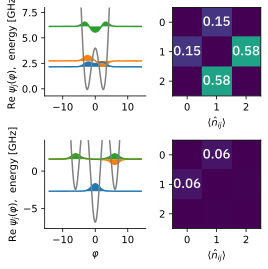

In [9]:
import scqubits
import matplotlib.pyplot as plt
import numpy as np
from scqubits.utils.plotting import add_numbers_to_axes


q1 = scqubits.Fluxonium(4,1,1,0.5,110,6)
q2 = scqubits.Fluxonium(6.86,1.46,0.23,0,110,6)


fig, axes = plt.subplots(2,2,figsize = (4,4))
fig.subplots_adjust(hspace=0.5)

_, wavefunction_ax =  q1.plot_wavefunction(which=[0,1,2], fig_ax=(fig, axes[0,0]))
wavefunction_ax.set_xlabel('')
_, wavefunction_ax =  q2.plot_wavefunction(which=[0,1,2], fig_ax=(fig, axes[1,0]))


from matplotlib.colors import Normalize
norm = Normalize(vmin=0, vmax=1)


import matplotlib as mpl
from scqubits.settings import matplotlib_settings
from matplotlib.axes import Axes
from numpy import ndarray
from typing import Callable
@mpl.rc_context(matplotlib_settings)
def add_numbers_to_axes(
    axes: Axes, matrix: ndarray, modefunc: Callable, fontsize: int = 8
) -> None:
    for y_index in range(matrix.shape[0]):
        for x_index in range(matrix.shape[1]):
            element = np.abs(matrix[y_index, x_index])
            if element < 1e-2:
                string = ''
            else:
                string = f"{element:.2f}"
            axes.text(
                x_index,
                y_index,
                string,
                va="center",
                ha="center",
                fontsize=fontsize,
                rotation=0,
                color="white",
            )


matrix = q1.matrixelement_table('n_operator',evals_count=3)
axes[0,1].imshow(np.abs(matrix), cmap='viridis', norm=norm,aspect='equal')
fig_width, fig_height = fig.get_size_inches()
box_width_inches = fig_width / matrix.shape[1]
box_height_inches = fig_height / matrix.shape[0]
font_size = min(box_width_inches, box_height_inches) * 10
add_numbers_to_axes(axes[0,1], matrix, np.abs, fontsize=font_size)
axes[0,1].set_xlabel(rf"$\leftangle \hat{{n}}_{{ij}} \rightangle$")
axes[0,1].set_xticks([0,1,2])
axes[0,1].set_xticklabels(['0','1','2'])

matrix = q2.matrixelement_table('n_operator',evals_count=3)
axes[1,1].imshow(np.abs(matrix), cmap='viridis', norm=norm,aspect='equal')
fig_width, fig_height = fig.get_size_inches()
box_width_inches = fig_width / matrix.shape[1]
box_height_inches = fig_height / matrix.shape[0]
font_size = min(box_width_inches, box_height_inches) * 10
add_numbers_to_axes(axes[1,1], matrix, np.abs, fontsize=font_size)
axes[1,1].set_xlabel(rf"$\leftangle \hat{{n}}_{{ij}} \rightangle$")
axes[1,1].set_xticks([0,1,2])
axes[1,1].set_xticklabels(['0','1','2'])


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq
from tqdm import tqdm
import matplotlib.colors as colors


# Step 1: Define your function
def ratio_of_matrix_ele(EC, EL):
    qbt = scq.Fluxonium(EJ=6.86, EC=EC, EL=EL, flux=0, cutoff=70, truncated_dim=3)
    matrix = qbt.matrixelement_table('n_operator', evals_count=3)
    ratio =  abs(matrix[1, 0]) / abs(matrix[1, 2])
    ge_rate = qbt.t1_effective(
                common_noise_options = dict(i = 0, 
                                            j = 1, 
                                            total = True,
                                            ),
                get_rate = True,
                )
    
    ef_rate = qbt.t1_effective(
                common_noise_options = dict(i = 1, 
                                            j = 2, 
                                            total = True,
                                            ),
                get_rate = True,
                )
    return ratio , ge_rate , ef_rate
# Step 2: Prepare the range of values for EC and EL
EC_values = np.linspace(0.05, 1.5, 50)  # Example ranges, adjust as needed
EL_values = np.linspace(0.03, 0.3, 50)  # Example ranges, adjust as needed

# # Step 3: Initialize an array to store the computed ratios
ratios = np.zeros((len(EC_values), len(EL_values)))
ge_rates = np.zeros((len(EC_values), len(EL_values)))
ef_rates = np.zeros((len(EC_values), len(EL_values)))

# # Step 4: Loop over EC and EL values
for i, EC in enumerate(tqdm(EC_values, desc='EC Loop')):
    for j, EL in enumerate(EL_values):
        tuple_returned = ratio_of_matrix_ele(EC, EL)
        ratios[i, j] = tuple_returned[0]
        ge_rates[i, j] = tuple_returned[1]
        ef_rates[i, j] = tuple_returned[2]
        

EC Loop: 100%|██████████| 50/50 [1:00:16<00:00, 72.33s/it]


In [43]:
# import pickle
# with open('pickles/sweep_Re.pkl', 'wb') as file:
#     pickle.dump((ratios,ge_rates,ef_rates), file)

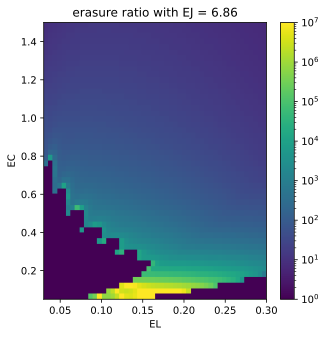

In [68]:

# Plot the heatmap
plt.figure(figsize=(5, 5))
plt.imshow(ratios, extent=[EL_values.min(), EL_values.max(), EC_values.min(), EC_values.max()],
           origin='lower', aspect='auto', cmap='viridis',
           norm=colors.LogNorm(vmin=1, vmax=1e7))  # Use LogNorm for logarithmic color scaling
plt.colorbar()
plt.xlabel('EL')
plt.ylabel('EC')
plt.title('erasure ratio with EJ = 6.86')
plt.show()

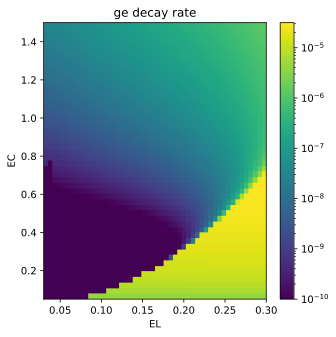

In [70]:

# Plot the heatmap
plt.figure(figsize=(5, 5))
plt.imshow(ge_rates, extent=[EL_values.min(), EL_values.max(), EC_values.min(), EC_values.max()],
           origin='lower', aspect='auto', cmap='viridis',
           norm=colors.LogNorm(
               vmin=1e-10, 
            #    vmax=1e-5,
               ))  # Use LogNorm for logarithmic color scaling
plt.colorbar()
plt.xlabel('EL')
plt.ylabel('EC')
plt.title("ge decay rate")

plt.show()

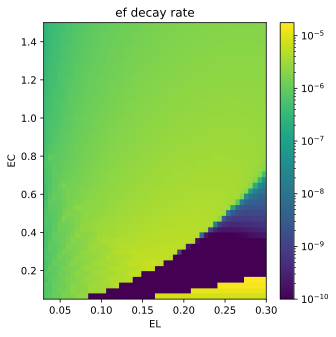

In [71]:

# Plot the heatmap
plt.figure(figsize=(5, 5))
plt.imshow(ef_rates, extent=[EL_values.min(), EL_values.max(), EC_values.min(), EC_values.max()],
           origin='lower', aspect='auto', cmap='viridis',
           norm=colors.LogNorm(
               vmin=1e-10, 
            #    vmax=1e-5,
               ))  # Use LogNorm for logarithmic color scaling
plt.colorbar()
plt.xlabel('EL')
plt.ylabel('EC')
plt.title("ef decay rate")
plt.show()

In [114]:
q2 = scqubits.Fluxonium(EJ = 6.86,
                        EC = 1.46,
                        EL = 0.23,
                        flux = 0,
                        cutoff = 110,
                        truncated_dim = 6)


print(f"")
q2.t1_inductive(i = 0,j = 1,get_rate = True,
    ),q2.t1_inductive(i = 1,j = 2,get_rate = True,
    ),q2.t1_quasiparticle_tunneling(i = 0,j = 1,get_rate = True,
    ),q2.t1_quasiparticle_tunneling(i = 1,j = 2,get_rate = True,
    ),q2.t1_charge_impedance(i = 0,j = 1,get_rate = True,
    ),q2.t1_charge_impedance(i = 1,j = 2,get_rate = True,
    ),q2.t1_capacitive(i = 0,j = 1,get_rate = True,
    ),q2.t1_capacitive(i = 1,j = 2,get_rate = True,
    ),q2.t1_effective(common_noise_options = dict(i = 1, j = 0, total = 1,),get_rate = True,
    ), q2.t1_effective(common_noise_options = dict(i = 2, j = 1, total = 1,),get_rate = True,
    )

(6.354264276400244e-11,
 1.6905477377153373e-06,
 7.622958729593092e-10,
 1.8069097672373148e-07,
 0.008384378073961373,
 1.1831257539541616e-05,
 3.704767664358283e-07,
 3.138435033445449e-09,
 3.725269392526047e-07,
 1.882086843992192e-06)

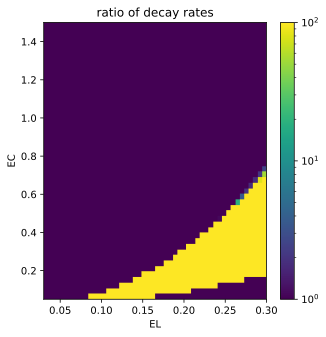

In [84]:

# Plot the heatmap
plt.figure(figsize=(5, 5))
plt.imshow(ge_rates/ef_rates, extent=[EL_values.min(), EL_values.max(), EC_values.min(), EC_values.max()],
           origin='lower', aspect='auto', cmap='viridis',
           norm=colors.LogNorm(
               vmin=1, 
               vmax=1e2,
               ))  # Use LogNorm for logarithmic color scaling
plt.colorbar()
plt.xlabel('EL')
plt.ylabel('EC')
plt.title("ratio of decay rates")
plt.show()

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

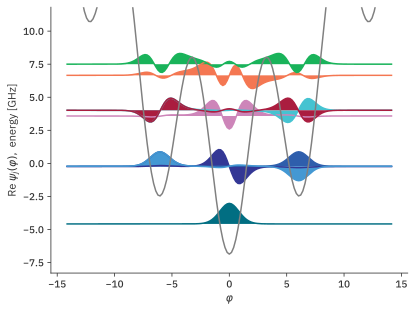

In [65]:
q2 = scqubits.Fluxonium(6.86,0.4,0.23,0,110,6)
q2.plot_wavefunction(which = [0,1,2,3,4,5,6,7,8])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

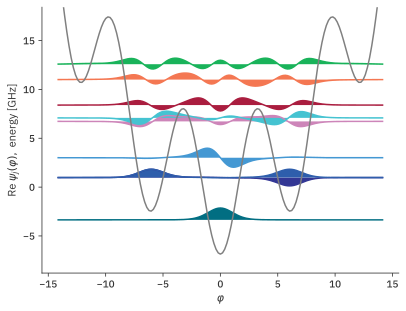

In [116]:
q2 = scqubits.Fluxonium(6.86,1,0.23,0,110,6)
q2.plot_wavefunction(which = [0,1,2,3,4,5,6,7,8])


In [104]:
qbt = scqubits.Fluxonium(6.86,1.46,0.13,   1e-4   ,110,6)

matrix = qbt.matrixelement_table('n_operator', evals_count=3)
ratio =  abs(matrix[1, 0]) / abs(matrix[1, 2])

ge_rate = qbt.t1_effective(
                common_noise_options = dict(i = 0, 
                                            j = 1, 
                                            total = True,
                                            ),
                get_rate = True,
                )

ef_rate = qbt.t1_effective(
            common_noise_options = dict(i = 1, 
                                        j = 2, 
                                        total = True,
                                        ),
            get_rate = True,
            )
ratio , ge_rate , ef_rate

(14.742234975346769, 9.761608721959466e-08, 1.2257336539406936e-06)

In [103]:
qbt = scqubits.Fluxonium(EJ = 6.86,
                         EC = 1.0,
                         EL = 0.15,  
                             flux = 1e-5    ,
                             
                             cutoff= 110,
                             truncated_dim = 6)

matrix = qbt.matrixelement_table('n_operator', evals_count=3)
ratio =  abs(matrix[1, 0]) / abs(matrix[1, 2])

ge_rate = qbt.t1_effective(
                common_noise_options = dict(i = 0, 
                                            j = 1, 
                                            total = True,
                                            ),
                get_rate = True,
                )

ef_rate = qbt.t1_effective(
            common_noise_options = dict(i = 1, 
                                        j = 2, 
                                        total = True,
                                        ),
            get_rate = True,
            )
ratio , ge_rate , ef_rate

(36.28637456562633, 1.6846739080082315e-08, 2.0032124209868924e-06)

In [1]:
import scqubits
import matplotlib.pyplot as plt
import numpy as np
from scqubits.utils.plotting import add_numbers_to_axes
q1 = scqubits.Fluxonium(4,1,1,          0.5,110,6)
q2 = scqubits.Fluxonium(4.5,1.5,0.23,   0,110,6)




In [5]:
q2.t1_effective(
                common_noise_options = dict(i = 0, 
                                            j = 1, 
                                            total = True,
                                            ),
                get_rate = True,
                )

3.1793026099041533e-06

In [6]:
q2.t1_effective(
                common_noise_options = dict(i = 1, 
                                            j = 2, 
                                            total = True,
                                            ),
                get_rate = True,
                )

9.627300698934491e-07

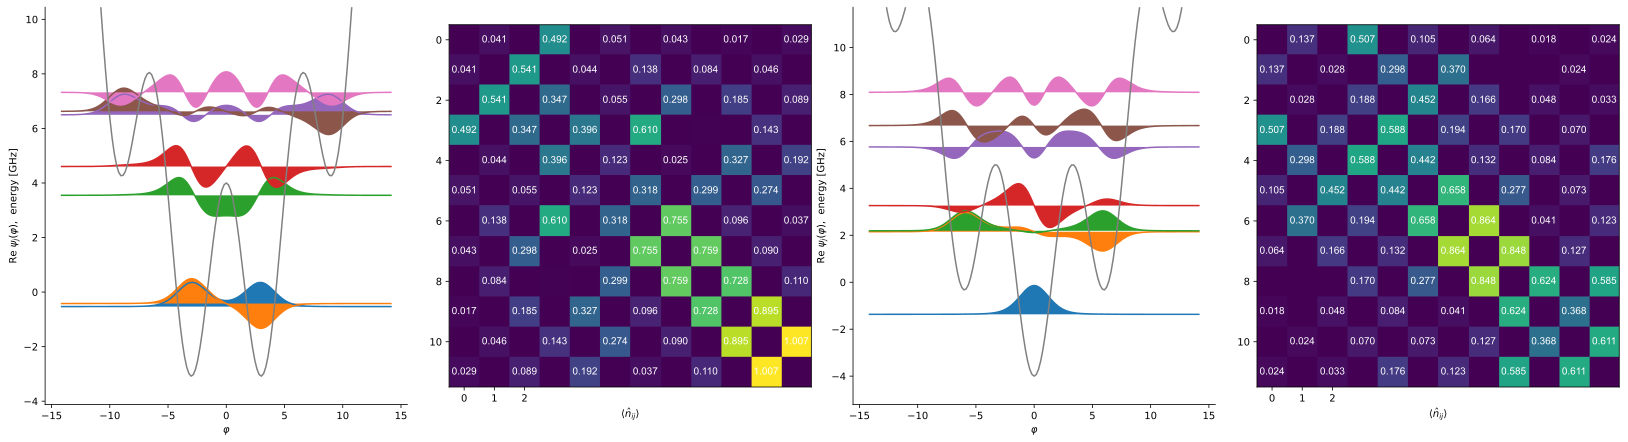

In [6]:
import scqubits
import matplotlib.pyplot as plt
import numpy as np
from scqubits.utils.plotting import add_numbers_to_axes
from matplotlib.colors import Normalize

# Initialize your qubits
q1 = scqubits.Fluxonium(4, 1, 4/20.5, 0.5, 110, 6)
q2 = scqubits.Fluxonium(4, 1, 4/20.5, 0, 110, 6)

# Create a 1x4 subplot layout
fig, axes = plt.subplots(1, 4, figsize=(7.5*3, 2*3), gridspec_kw={'width_ratios': [1, 1, 1, 1]})

# Plot wavefunctions for q1 and q2
_, wavefunction_ax = q1.plot_wavefunction(which=[0, 1, 2, 3,4,5,6], fig_ax=(fig, axes[0]))
# wavefunction_ax.set_xlabel('')
_, wavefunction_ax = q2.plot_wavefunction(which=[0, 1, 2, 3,4,5,6], fig_ax=(fig, axes[2]))

# Normalize the color scale
norm = Normalize(vmin=0, vmax=1)


import matplotlib as mpl
from scqubits.settings import matplotlib_settings
from matplotlib.axes import Axes
from numpy import ndarray
from typing import Callable
@mpl.rc_context(matplotlib_settings)
def add_numbers_to_axes(
    axes: Axes, matrix: ndarray, modefunc: Callable, fontsize: int = 8
) -> None:
    for y_index in range(matrix.shape[0]):
        for x_index in range(matrix.shape[1]):
            element = np.abs(matrix[y_index, x_index])
            if element < 1e-2:
                string = ''
            else:
                string = f"{element:.3f}"
            axes.text(
                x_index,
                y_index,
                string,
                va="center",
                ha="center",
                fontsize=fontsize,
                rotation=0,
                color="white",
            )


# Plot matrix elements for q1
matrix = q1.matrixelement_table('n_operator', evals_count=12)
im = axes[1].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
# fig.colorbar(im, ax=axes[1])  # Optional: Add a colorbar for this heatmap
add_numbers_to_axes(axes[1], matrix, np.abs, fontsize=10)
axes[1].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['0','1','2'])

# Plot matrix elements for q2
matrix = q2.matrixelement_table('n_operator', evals_count=12)
im = axes[3].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
# fig.colorbar(im, ax=axes[3])  # Optional: Add a colorbar for this heatmap
add_numbers_to_axes(axes[3], matrix, np.abs, fontsize=10)
axes[3].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[3].set_xticks([0,1,2])
axes[3].set_xticklabels(['0','1','2'])

plt.tight_layout(pad=0.1)  # Adjust layout to make sure everything fits without overlapping
plt.show()


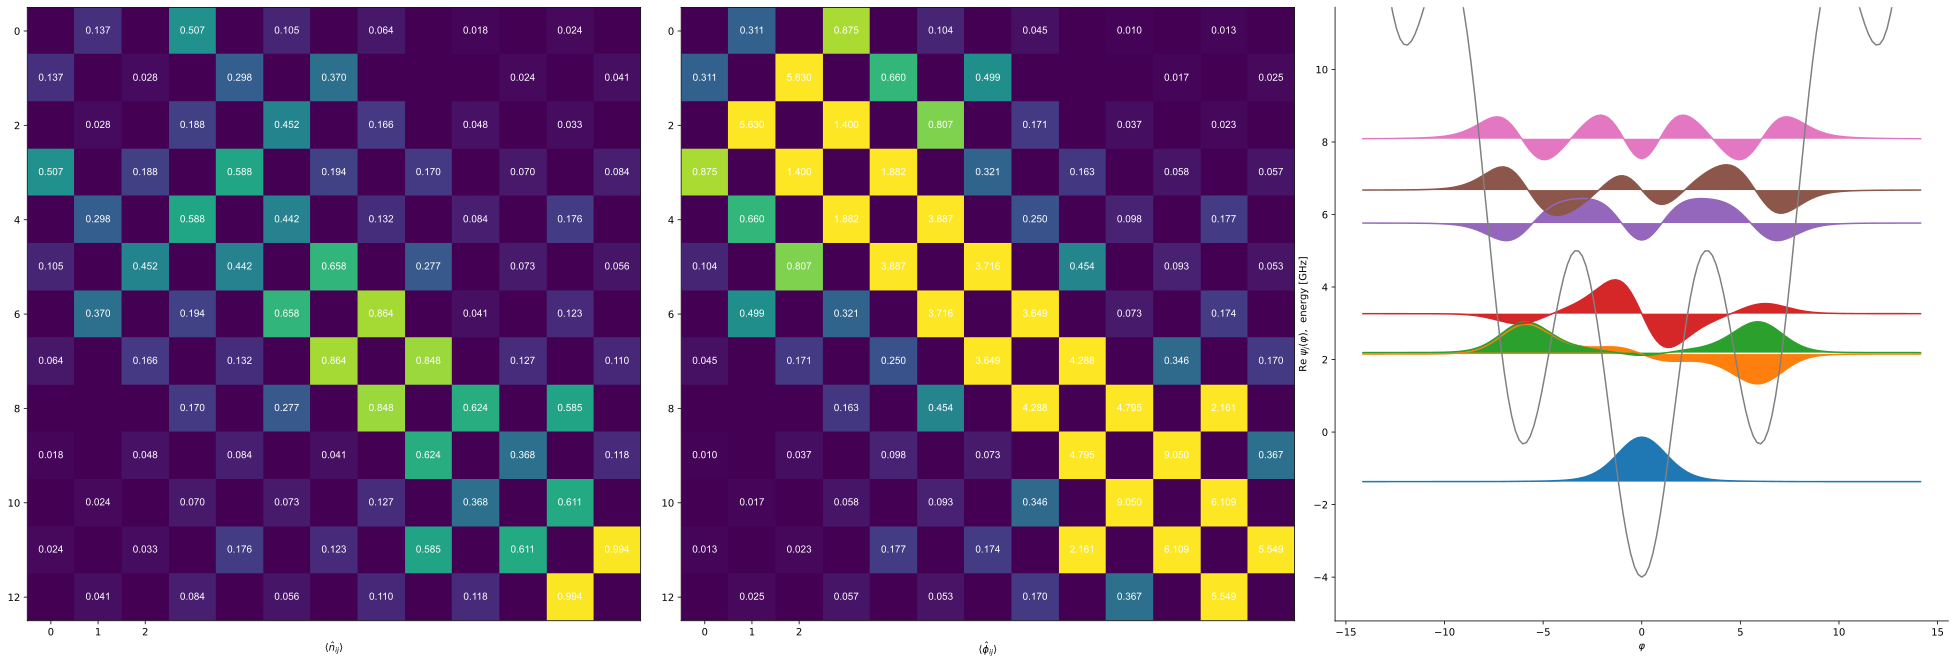

In [50]:
q2 = scqubits.Fluxonium(4, 1, 4/20.5, 0, 110, 6)
fig, axes = plt.subplots(1,3,figsize=(27,9))
matrix = q2.matrixelement_table('n_operator', evals_count=13)
im = axes[0].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[0], matrix, np.abs, fontsize=10)
axes[0].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels(['0','1','2'])

matrix = q2.matrixelement_table('phi_operator', evals_count=13)
im = axes[1].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[1], matrix, np.abs, fontsize=10)
axes[1].set_xlabel(rf"$\langle \hat{{\phi}}_{{ij}} \rangle$")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['0','1','2'])

q2.plot_wavefunction(which=[0, 1, 2, 3,4,5,6], fig_ax=(fig, axes[2]))

plt.tight_layout(pad=0.1) 
plt.show()


Spectral data:   0%|          | 0/40 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\Phi_{ext}/\\Phi_0$', ylabel='energy [GHz]'>)

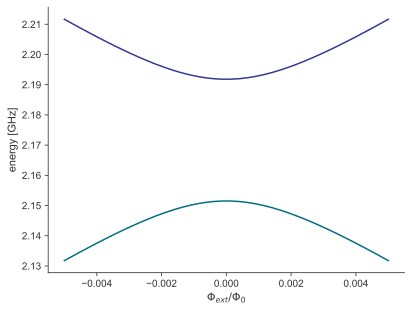

In [41]:
fluxvals = np.linspace(-0.005, 0.005, 40)
specdata = q2.get_spectrum_vs_paramvals( param_name='flux', param_vals=fluxvals)
plot.evals_vs_paramvals(specdata, which=[1,2])

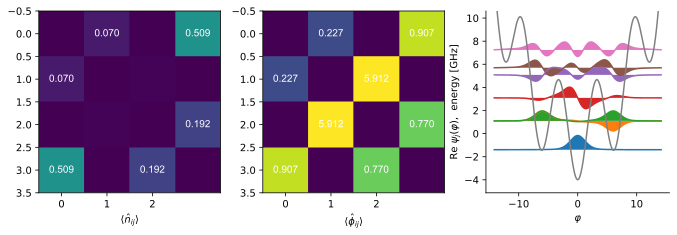

In [35]:
q2 = scqubits.Fluxonium(4, 1, 4/30, 0, 110, 6)
fig, axes = plt.subplots(1,3,figsize=(9,3))
matrix = q2.matrixelement_table('n_operator', evals_count=4)
im = axes[0].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[0], matrix, np.abs, fontsize=10)
axes[0].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels(['0','1','2'])

matrix = q2.matrixelement_table('phi_operator', evals_count=4)
im = axes[1].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[1], matrix, np.abs, fontsize=10)
axes[1].set_xlabel(rf"$\langle \hat{{\phi}}_{{ij}} \rangle$")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['0','1','2'])

q2.plot_wavefunction(which=[0, 1, 2, 3,4,5,6], fig_ax=(fig, axes[2]))

plt.tight_layout(pad=0.1) 
plt.show()

Spectral data:   0%|          | 0/40 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\Phi_{ext}/\\Phi_0$', ylabel='energy [GHz]'>)

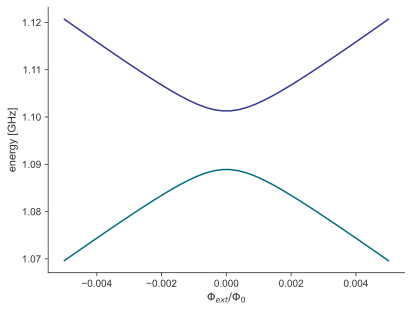

In [37]:
fluxvals = np.linspace(-0.005, 0.005, 40)
specdata = q2.get_spectrum_vs_paramvals( param_name='flux', param_vals=fluxvals)
plot.evals_vs_paramvals(specdata, which=[1,2])

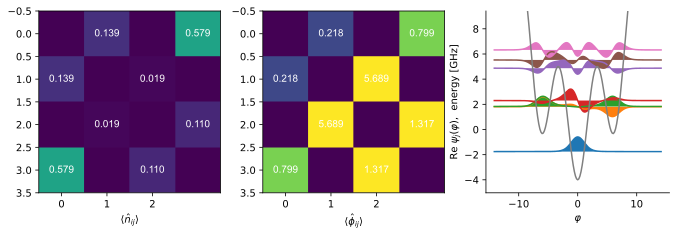

In [38]:
q2 = scqubits.Fluxonium(4, 0.7, 4/20.5, 0, 110, 6)
fig, axes = plt.subplots(1,3,figsize=(9,3))
matrix = q2.matrixelement_table('n_operator', evals_count=4)
im = axes[0].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[0], matrix, np.abs, fontsize=10)
axes[0].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels(['0','1','2'])

matrix = q2.matrixelement_table('phi_operator', evals_count=4)
im = axes[1].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[1], matrix, np.abs, fontsize=10)
axes[1].set_xlabel(rf"$\langle \hat{{\phi}}_{{ij}} \rangle$")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['0','1','2'])

q2.plot_wavefunction(which=[0, 1, 2, 3,4,5,6], fig_ax=(fig, axes[2]))

plt.tight_layout(pad=0.1) 
plt.show()

Spectral data:   0%|          | 0/40 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\Phi_{ext}/\\Phi_0$', ylabel='energy [GHz]'>)

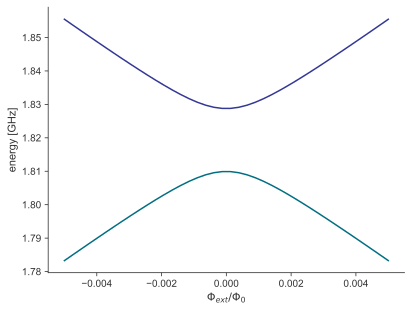

In [39]:
fluxvals = np.linspace(-0.005, 0.005, 40)
specdata = q2.get_spectrum_vs_paramvals( param_name='flux', param_vals=fluxvals)
plot.evals_vs_paramvals(specdata, which=[1,2])

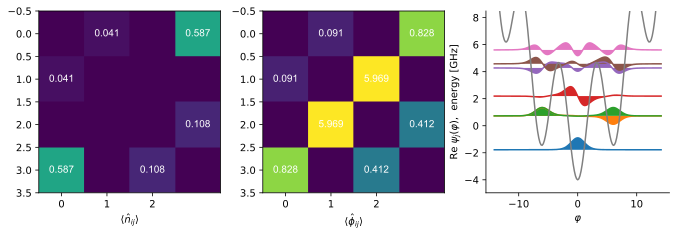

In [46]:
q2 = scqubits.Fluxonium(4, 0.7, 4/30, 0, 110, 6)
fig, axes = plt.subplots(1,3,figsize=(9,3))
matrix = q2.matrixelement_table('n_operator', evals_count=4)
im = axes[0].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[0], matrix, np.abs, fontsize=10)
axes[0].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels(['0','1','2'])

matrix = q2.matrixelement_table('phi_operator', evals_count=4)
im = axes[1].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
add_numbers_to_axes(axes[1], matrix, np.abs, fontsize=10)
axes[1].set_xlabel(rf"$\langle \hat{{\phi}}_{{ij}} \rangle$")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['0','1','2'])

q2.plot_wavefunction(which=[0, 1, 2, 3,4,5,6], fig_ax=(fig, axes[2]))

plt.tight_layout(pad=0.1) 
plt.show()

Spectral data:   0%|          | 0/40 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\Phi_{ext}/\\Phi_0$', ylabel='energy [GHz]'>)

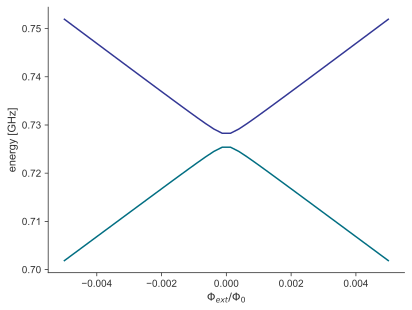

In [47]:
fluxvals = np.linspace(-0.005, 0.005, 40)
specdata = q2.get_spectrum_vs_paramvals( param_name='flux', param_vals=fluxvals)
plot.evals_vs_paramvals(specdata, which=[1,2])

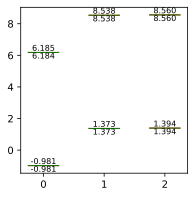

In [60]:
from bidict import bidict
from utils_basic_funcs import generate_single_mapping
qubit = scqubits.Fluxonium(EJ = 2.65,EC = 0.6, EL = 0.13,cutoff=110,truncated_dim=8,flux=0)
resonator =  scqubits.Oscillator(E_osc=7.16518677,truncated_dim=3,l_osc=1.0)

hilbertspace = scqubits.HilbertSpace([qubit, resonator])
hilbertspace.add_interaction(g_strength=0.13,op1=qubit.n_operator, op2=resonator.n_operator,add_hc=False)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
product_to_dressed = bidict(product_to_dressed)

bare_levels = [
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [2,0],
    [2,1]
]
qls = [product[0] for product in bare_levels]
rls = [product[1] for product in bare_levels]
max_qubit_level = max(qls) +1 
max_resonator_level = max(rls) +1
qubit_ori_energies = qubit.eigenvals(max_qubit_level)
resonator_ori_energies = resonator.eigenvals(max_resonator_level)

energy_text_size = 8
fig, ax = plt.subplots(1, 1, figsize=(3, 3))

for ql, rl in zip(qls, rls):
    original = (qubit_ori_energies[ql] + resonator_ori_energies[rl])#* 2 * np.pi
    x1,x2 = ql-0.25,ql+0.25
    ax.plot([x1, x2], [original, original], linewidth=1, color='red')
    ax.text(ql, original, f"{original:.3f}", fontsize=energy_text_size, ha='center', va='bottom')

    dressed_state_index = product_to_dressed[(ql,rl)]
    dressed = hilbertspace.energy_by_dressed_index(dressed_state_index)#* 2 * np.pi
    ax.plot([x1, x2], [dressed, dressed], linewidth=1, color='green')
    ax.text(ql, dressed, f"{dressed:.3f}", fontsize=energy_text_size, ha='center', va='top')

plt.show()


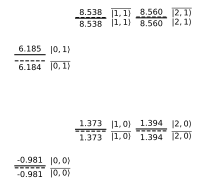

In [112]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

for ql, rl in zip(qls, rls):
    original = (qubit_ori_energies[ql] + resonator_ori_energies[rl])#* 2 * np.pi
    x1,x2 = ql-0.25,ql+0.25
    ax.plot([x1, x2], [original, original], linewidth=1, color='black',linestyle = '-')
    ax.text(ql, original+0.1, f"{original:.3f}", fontsize=energy_text_size, ha='center', va='bottom')
    


    dressed_state_index = product_to_dressed[(ql,rl)]
    dressed_value = hilbertspace.energy_by_dressed_index(dressed_state_index)#* 2 * np.pi
    delta = dressed_value-original
    dressed_plot_value = dressed_value + delta * 500
    ax.plot([x1, x2], [dressed_plot_value, dressed_plot_value], linewidth=1, color='black',linestyle = '--')
    ax.text(ql, dressed_plot_value-0.2, f"{dressed_value:.3f}", fontsize=energy_text_size, ha='center', va='top')

    if ql == 1 or ql == 2:
        if rl == 0:
            y_adjust = -0.3
        else:
            y_adjust = 0.3
    else:
        if rl == 0:
            y_adjust = -0.3
        else:
            y_adjust = -0.3

    dressed_plot_value = dressed_plot_value + y_adjust
    ax.text(ql+0.5, dressed_plot_value, rf"$\overline{{|{ql},{rl}\rangle}}$", fontsize=energy_text_size, ha='center', va='center')

    original_plot_value = original -y_adjust
    ax.text(ql+0.5, original_plot_value, rf"$|{ql},{rl}\rangle$", fontsize=energy_text_size, ha='center', va='center')

ax.set_xticks([])
ax.set_yticks([])

ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

